# Introduction

Seattle and Berkeley are both located on the west coast of the United States and at nearly the same longitude, but Seattle is much farther north. I chose Berkeley as a comparison city because I wanted to see how precipitation patterns differ between two cities that are geographically aligned north-to-south but have different climates. The goal of this project is to determine whether it rains more in Seattle than in Berkeley.

# Data Source

The precipitation data for Seattle, Washington and Berkeley, California were obtained from the **NOAA National Centers for Environmental Information (NCEI)** using the **Global Historical Climatology Network Daily (GHCN-Daily)** dataset.

The data were downloaded from:

https://www.ncei.noaa.gov/cdo-web/search?datasetid=GHCND

For this project, I used daily precipitation observations from **2018 through 2022** for both cities. The `PRCP` variable represents daily precipitation and is the main variable used in the analysis.

## Load and explore the data

### Import libraries

In [1]:
# Import pandas, numby, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import seaborn
import seaborn as sns

# Set the plotting style
sns.set_style("whitegrid")

### Load the data

In [2]:
# Load the Seattle data set
df_seattle = pd.read_csv("../data/seattle_rain.csv")

In [3]:
type(df_seattle)

pandas.core.frame.DataFrame

In [4]:
# Load the Berkeley data set
df_berkeley = pd.read_csv("../data/berkeley_rain.csv")

In [5]:
type(df_berkeley)

pandas.core.frame.DataFrame

## Explore the contents of the data sets

In [6]:
df_seattle.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/1/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/2/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/3/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/4/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/5/18,NaN,NaN,0.25,NaN,NaN,NaN,NaN


In [7]:
df_berkeley.head()

,STATION,NAME,DATE,PRCP
0,USC00040693,"BERKELEY, CA US",2018-01-01,0.00
1,USC00040693,"BERKELEY, CA US",2018-01-02,0.00
2,USC00040693,"BERKELEY, CA US",2018-01-03,0.00
3,USC00040693,"BERKELEY, CA US",2018-01-04,0.24
4,USC00040693,"BERKELEY, CA US",2018-01-05,0.03


In [8]:
df_seattle.columns

Index(['STATION', 'NAME', 'DATE', 'DAPR', 'MDPR', 'PRCP', 'SNOW', 'SNWD',
       'WESD', 'WESF'],
      dtype='object')

In [9]:
df_berkeley.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP'], dtype='object')

The seattle dataset has 10 columns while berkeley dataset just has only 4 columns. However, we only need DATE and PRCP so those are good enough

#### Initial Data Exploration

In [10]:
df_seattle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   object 
 1   NAME     1658 non-null   object 
 2   DATE     1658 non-null   object 
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), object(3)
memory usage: 129.7+ KB


Seattle dataset has 1658 entries and 22 null value in PRCP

In [11]:
df_berkeley.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1668 entries, 0 to 1667
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1668 non-null   object 
 1   NAME     1668 non-null   object 
 2   DATE     1668 non-null   object 
 3   PRCP     1355 non-null   float64
dtypes: float64(1), object(3)
memory usage: 52.3+ KB


Berkley dataset has 1668 entries and 313 null value in PRCP

#### Compare Dataset Sizes

In [12]:
df_seattle.shape

(1658, 10)

In [13]:
df_berkeley.shape

(1668, 4)

There are 10 rows different between seattle and berkeley dataset

### Exploring DataFrame Columns

#### Examine STATION column

In [14]:
# Check number unique station in seattle dataset
df_seattle['STATION'].nunique()

1

Seattle dataset just has only 1 unique station

In [15]:
# Check number of unique station in berkeley dataset
df_berkeley['STATION'].nunique()

1

Berkeley dataset also has only 1 unique station

#### Examine DATE column

In [16]:
df_seattle['DATE']

0         1/1/18
1         1/2/18
2         1/3/18
3         1/4/18
4         1/5/18
          ...   
1653    12/27/22
1654    12/28/22
1655    12/29/22
1656    12/30/22
1657    12/31/22
Name: DATE, Length: 1658, dtype: object

In [17]:
df_berkeley['DATE']

0       2018-01-01
1       2018-01-02
2       2018-01-03
3       2018-01-04
4       2018-01-05
           ...    
1663    2022-12-27
1664    2022-12-28
1665    2022-12-29
1666    2022-12-30
1667    2022-12-31
Name: DATE, Length: 1668, dtype: object

DATE in seattle dataset and berkley data set is not DATE datatype

#### Convert DATE to dataframe

In [18]:
df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'])
df_seattle['DATE']

/tmp/ipykernel_68564/1266338797.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'])


0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1653   2022-12-27
1654   2022-12-28
1655   2022-12-29
1656   2022-12-30
1657   2022-12-31
Name: DATE, Length: 1658, dtype: datetime64[ns]

In [19]:
df_berkeley['DATE'] = pd.to_datetime(df_berkeley['DATE'])
df_berkeley['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1663   2022-12-27
1664   2022-12-28
1665   2022-12-29
1666   2022-12-30
1667   2022-12-31
Name: DATE, Length: 1668, dtype: datetime64[ns]

#### Checking data range date

In [20]:
df_seattle['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

In [21]:
df_berkeley['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

### Plot the daily precipitation data

#### Seattle dataset

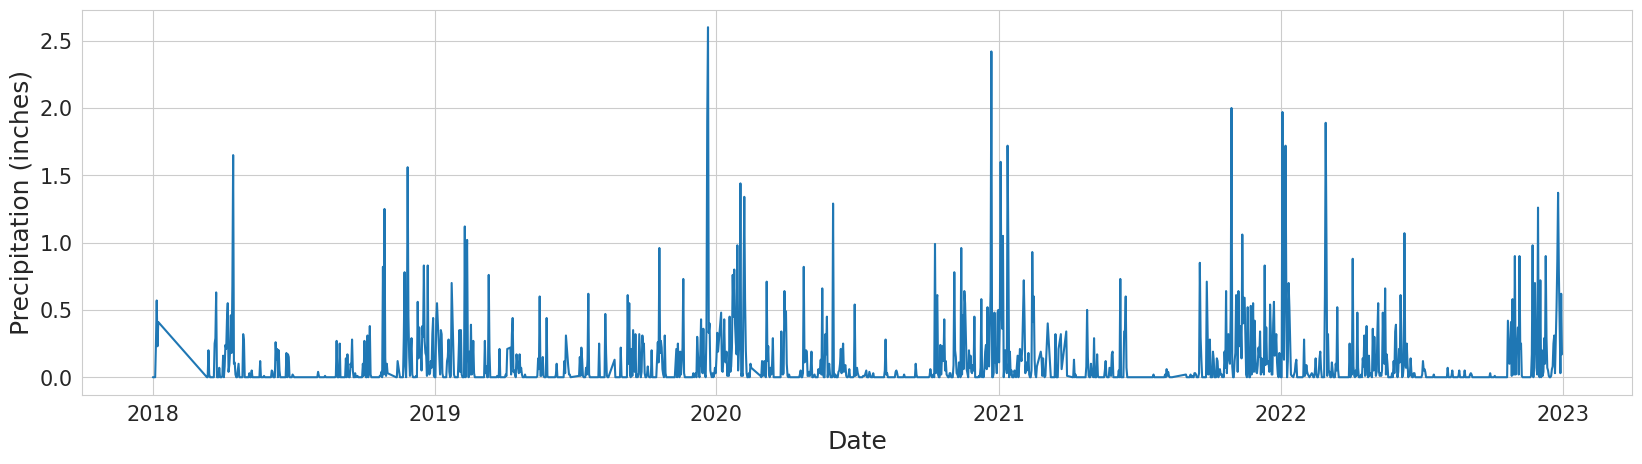

In [22]:
plt.figure(figsize = (20, 5))

sns.lineplot(data = df_seattle, x = 'DATE', y = 'PRCP')

# Label
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Precipitation (inches)', fontsize = 18)

plt.tick_params(labelsize = 15)

plt.show()

**There is a straight line from the first quarter of 2018 -> Missing value**

#### Bekerley dataset

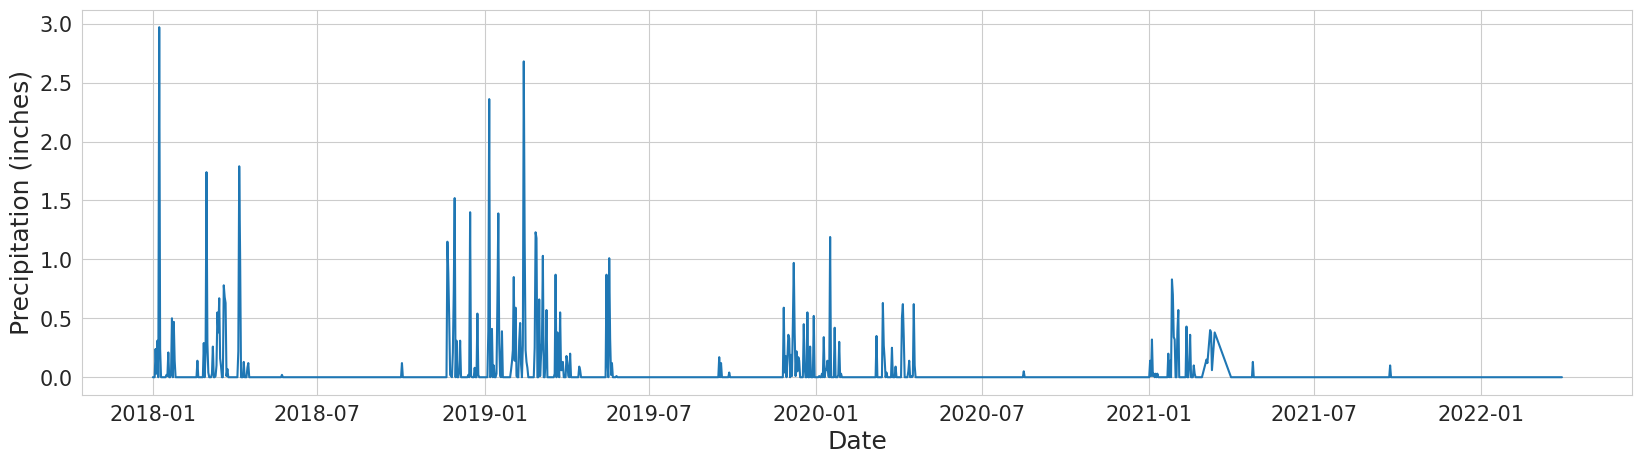

In [23]:
plt.figure(figsize = (20, 5))

sns.lineplot(data = df_berkeley, x = 'DATE', y = 'PRCP')

# Label
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Precipitation (inches)', fontsize = 18)

plt.tick_params(labelsize = 15)

plt.show()

**Berkeley dataset have a lot of missing data that's  why there is some gap. Also berkeley has summer season which does not have rain**

### Join dataframes keeping DATE and PRCP columns

In [24]:
df_seattle.head(2)

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-01,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-02,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [25]:
df_berkeley.head(2)

,STATION,NAME,DATE,PRCP
0,USC00040693,"BERKELEY, CA US",2018-01-01,0.0
1,USC00040693,"BERKELEY, CA US",2018-01-02,0.0


#### Use outer join to keep all dates present

In [26]:
df = df_berkeley[['DATE', 'PRCP']].merge(df_seattle[['DATE','PRCP']], on = 'DATE', how = 'outer')

In [27]:
df

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.24,0.00
4,2018-01-05,0.03,0.25
...,...,...,...
1814,2022-12-27,NaN,0.78
1815,2022-12-28,NaN,0.40
1816,2022-12-29,NaN,0.03
1817,2022-12-30,NaN,0.62


##### How many data points should we have from 2018 to 2022:
365 x 5 + 1 = 1826 days
Rigt here we just have 1819 rows = 1819 days so there is still 7 days missing after join the dataset

#### Find and add that 7 days to the dataset

In [28]:
# Create all dates that should exist
complete_dates = pd.DataFrame({
    'DATE': pd.date_range(
        start='2018-01-01',
        end='2022-12-31',
        freq='D'
    )
})

# Merge that all date to the dataset
df = complete_dates.merge(
    df,
    on='DATE',
    how='left'
)

In [29]:
df

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.24,0.00
4,2018-01-05,0.03,0.25
...,...,...,...
1821,2022-12-27,NaN,0.78
1822,2022-12-28,NaN,0.40
1823,2022-12-29,NaN,0.03
1824,2022-12-30,NaN,0.62


#### Create a tidy data frame with columns for city and precipitation

In [30]:
df = pd.melt(df, id_vars = 'DATE', var_name = 'city', value_name = 'precipitation' )

In [31]:
df

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.00
1,2018-01-02,PRCP_x,0.00
2,2018-01-03,PRCP_x,0.00
3,2018-01-04,PRCP_x,0.24
4,2018-01-05,PRCP_x,0.03
...,...,...,...
3647,2022-12-27,PRCP_y,0.78
3648,2022-12-28,PRCP_y,0.40
3649,2022-12-29,PRCP_y,0.03
3650,2022-12-30,PRCP_y,0.62


#### Rename the city values 'BER' and 'SEA'

In [32]:
df.loc[df['city'] == 'PRCP_x', 'city'] = 'BER'
df.loc[df['city'] == 'PRCP_y', 'city'] = 'SEA'

In [33]:
df

,DATE,city,precipitation
0,2018-01-01,BER,0.00
1,2018-01-02,BER,0.00
2,2018-01-03,BER,0.00
3,2018-01-04,BER,0.24
4,2018-01-05,BER,0.03
...,...,...,...
3647,2022-12-27,SEA,0.78
3648,2022-12-28,SEA,0.40
3649,2022-12-29,SEA,0.03
3650,2022-12-30,SEA,0.62


#### Rename the column

In [34]:
df = df.rename(columns = {'DATE': 'date'})

In [35]:
df

,date,city,precipitation
0,2018-01-01,BER,0.00
1,2018-01-02,BER,0.00
2,2018-01-03,BER,0.00
3,2018-01-04,BER,0.24
4,2018-01-05,BER,0.03
...,...,...,...
3647,2022-12-27,SEA,0.78
3648,2022-12-28,SEA,0.40
3649,2022-12-29,SEA,0.03
3650,2022-12-30,SEA,0.62


### Handle missing data

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[ns]
 1   city           3652 non-null   object        
 2   precipitation  2991 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 85.7+ KB


In [37]:
# Get number of non missing data
df.notna().sum()

date             3652
city             3652
precipitation    2991
dtype: int64

In [38]:
df.loc[df['city'] == 'BER', 'precipitation'].isna().sum()

471

In [39]:
df.loc[df['city'] == 'SEA', 'precipitation'].isna().sum()

190

##### How many data points should we have from 2018 to 2022:
365 x 5 + 1 = 1826 days

In [40]:
# Define a column that labels each day by day of the year: 1, 2, 3,... 365
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year

In [41]:
df.head()

,date,city,precipitation,day_of_year
0,2018-01-01,BER,0.00,1
1,2018-01-02,BER,0.00,2
2,2018-01-03,BER,0.00,3
3,2018-01-04,BER,0.24,4
4,2018-01-05,BER,0.03,5


I would like to use mean precipitaion for each day average across year to fill the missing value but the worst scenario is all day of 5 years is missing so I would like to check it first. Escpecially, Berkeley has over 25% missing data (471 days).

#### Handle Berkeley missing data

In [57]:
# Get all missing date of Berkeley
df_missing_berkeley = df[(df['precipitation'].isna() == True) & (df['city'] == "BER")]
df_missing_berkeley

,date,city,precipitation,day_of_year
638,2019-10-01,BER,NaN,274
639,2019-10-02,BER,NaN,275
640,2019-10-03,BER,NaN,276
641,2019-10-04,BER,NaN,277
642,2019-10-05,BER,NaN,278
...,...,...,...,...
1821,2022-12-27,BER,NaN,361
1822,2022-12-28,BER,NaN,362
1823,2022-12-29,BER,NaN,363
1824,2022-12-30,BER,NaN,364


##### **Count missing day follow by day_of_year**

In [104]:
berkeley_day_count_missing = df_missing_berkeley.groupby('day_of_year').size().reset_index(name = 'missing_count')
berkeley_day_count_missing

,day_of_year,missing_count
0,60,1
1,61,1
2,62,1
3,63,1
4,66,1
...,...,...
296,362,2
297,363,2
298,364,2
299,365,2


#### How many day_of_year have 3 and 4 missing day?


In [105]:
berkeley_day_count_missing[(berkeley_day_count_missing['missing_count'].isin([3,4]))] 

,day_of_year,missing_count
208,274,3
209,275,4
210,276,4
211,277,4
212,278,4
213,279,4
214,280,4
215,281,4
216,282,4
217,283,4


**From day 274 to day 319, there are 45 consecutive days with 3 to 4 missing values across the 5-year period, which can produce unreliable mean precipitation estimates for those days.**

#### Better solution to handle Berkeley missing data

Because precipitation has a strong seasonal pattern, historical Berkeley precipitation data were divided into three periods. Data from 1998 through 2013 were used to train the ARIMA model. Data from 2014 through 2017 were used as a test set to evaluate how well the model predicted unseen precipitation values. After evaluating the model, it was retrained using all available data from 1998 through 2017 and used to predict precipitation from 2018 through 2022. These predictions were used only to replace missing precipitation values, while observed values were kept unchanged.

In [109]:
# import ARIMA model from sklearn
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

##### Load the berkeley training dataset

In [131]:
berkeley_25 = pd.read_csv("../data/berkeley_25_years.csv")

In [132]:
berkeley_25.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD
0,USC00040693,"BERKELEY, CA US",1998-01-01,NaN,NaN,0.00,0.0,0.0
1,USC00040693,"BERKELEY, CA US",1998-01-02,NaN,NaN,0.00,0.0,0.0
2,USC00040693,"BERKELEY, CA US",1998-01-03,NaN,NaN,0.00,0.0,0.0
3,USC00040693,"BERKELEY, CA US",1998-01-04,NaN,NaN,0.00,0.0,0.0
4,USC00040693,"BERKELEY, CA US",1998-01-05,NaN,NaN,1.85,0.0,0.0


#### Clean the Berkeley 25 years data

In [133]:
# select only DATE, PRCP and rename
berkeley_25 = berkeley_25[['DATE', 'PRCP']].rename(columns={'DATE':'date', 'PRCP':'precipitation'})

In [134]:
# Convert date to dataframe
berkeley_25['date'] = pd.to_datetime(berkeley_25['date'])

In [135]:
# Set date as index
berkeley_25 = berkeley_25.set_index('date').sort_index()

In [136]:
# Make sure every calendar day exist
berkeley_25 = berkeley_25.asfreq('D')

In [142]:
berkeley_25

,precipitation
date,
1998-01-01,0.00
1998-01-02,0.00
1998-01-03,0.00
1998-01-04,0.00
1998-01-05,1.85
...,...
2022-10-27,NaN
2022-10-28,NaN
2022-10-29,NaN


In [143]:
berkeley_25.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9070 entries, 1998-01-01 to 2022-10-31
Freq: D
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   precipitation  8278 non-null   float64
dtypes: float64(1)
memory usage: 141.7 KB


In [137]:
berkeley_25['precipitation'].isna().sum()

792

The Berkeley dataset contains 9,070 daily observations, of which 792 precipitation values are missing. Since the missing values represent a relatively small proportion of the full dataset, the missing observations are retained as NaN values rather than removed. The ARIMA model can be fitted using the available observations while preserving the continuous daily time index.

#### Split the Berkeley 25 years data to training, testing, and target dataset

In [146]:
# training dataset from 1998 to 2013
train = berkeley_25.loc['1998-01-01':'2013-12-31'].copy()

In [147]:
# testing dataset from 2014 to 2017
test = berkeley_25.loc['2014-01-01':'2017-12-31'].copy()

In [148]:
# target (predict) dataset from 2015 to 2022
target = berkeley_25.loc['2015-01-01':'2022-12-31'].copy()

In [149]:
# Check size
print("Train", train.shape)
print("Test", test.shape)
print("Target", target.shape)

Train (5844, 1)
Test (1461, 1)
Target (2861, 1)


#### Train the data with ARIMA model

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['precipitation'],
    order=(2, 0, 1),
    seasonal_order=(1, 0, 0, 365)
)

model_fit = model.fit()

/home/phuc/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/phuc/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
print(model_fit.summary())

#### Predict the 2014-2017 data

In [153]:
test_prediction = model_fit.forecast(steps = len(test))

In [156]:
# make sure the predict value use the same day
test_prediction.index = test.index

# precipitaition cannot be negative
test_prediction = test_prediction.clip(lower = 0)

#### Compare predictions with the actual test data

In [157]:
# Evaluate onlu the dates where we actually know the precipitation
test_observed = test['precipitation'].notna()

#### Calculate MAE

In [159]:
mae = mean_absolute_error(
    test.loc[test_observed, 'precipitation'],
    test_prediction.loc[test_observed]
)

print(f"MAE: {mae:.4f} inches")

MAE: 0.1294 inches


#### Calculate RMSE

In [160]:
rmse = np.sqrt(
    mean_squared_error(
        test.loc[test_observed, 'precipitation'],
        test_prediction.loc[test_observed]
    )
)

print(f"RMSE: {rmse:.4f} inches")

RMSE: 0.2914 inches


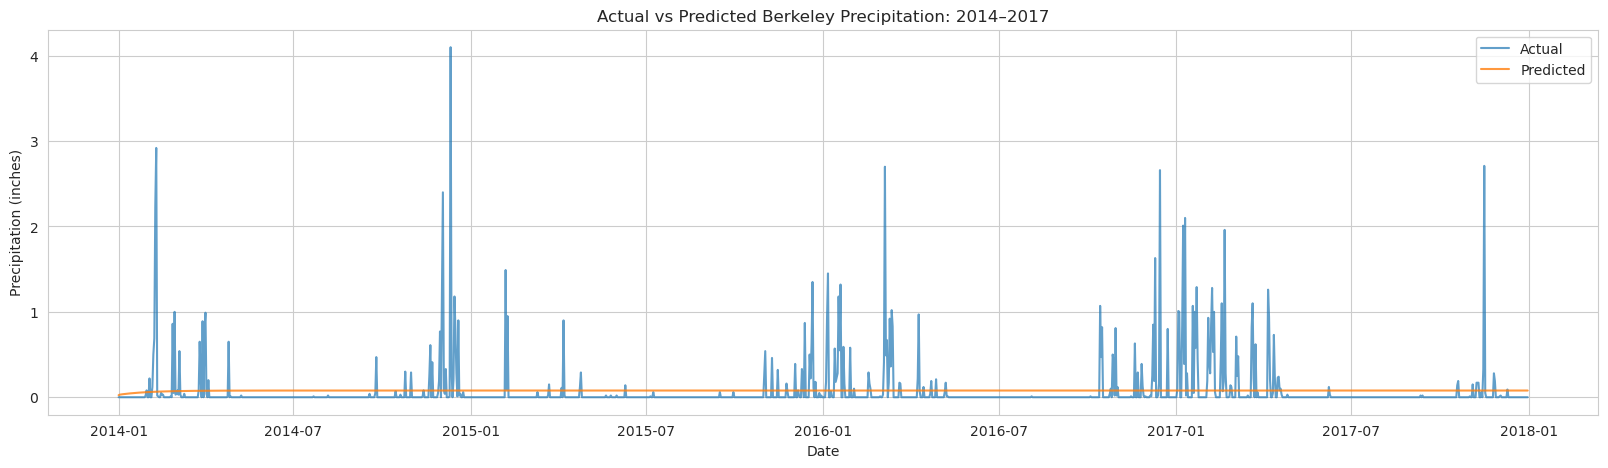

In [161]:
plt.figure(figsize=(20, 5))

plt.plot(
    test.index,
    test['precipitation'],
    label='Actual',
    alpha=0.7
)

plt.plot(
    test_prediction.index,
    test_prediction,
    label='Predicted',
    alpha=0.8
)

plt.xlabel('Date')
plt.ylabel('Precipitation (inches)')
plt.title('Actual vs Predicted Berkeley Precipitation: 2014–2017')

plt.legend()

plt.show()

#### Impute missing values
I will replace missing values with the mean across years of values on that day.

**Design an algorithm for replacing missing values with the mean across years of values on that day**

In [42]:
# Compute the mean precipitation for each day in _, average across year
def mean_day_precipitation(location):
    mean_day_precipitation = df.loc[
        df['city'] == location,
        ['precipitation', 'day_of_year']
    ].groupby('day_of_year').mean()
    return mean_day_precipitation

In [43]:
# mean precipitation in Seatlle, average across year
mean_day_precipitation_seattle = mean_day_precipitation('SEA')
mean_day_precipitation_seattle

,precipitation
day_of_year,
1,0.052000
2,0.150000
3,0.836000
4,0.370000
5,0.246667
...,...
362,0.120000
363,0.102000
364,0.268000


In [44]:
# Check if there is missing value in average across year
mean_day_precipitation_seattle['precipitation'].isna().sum()

0

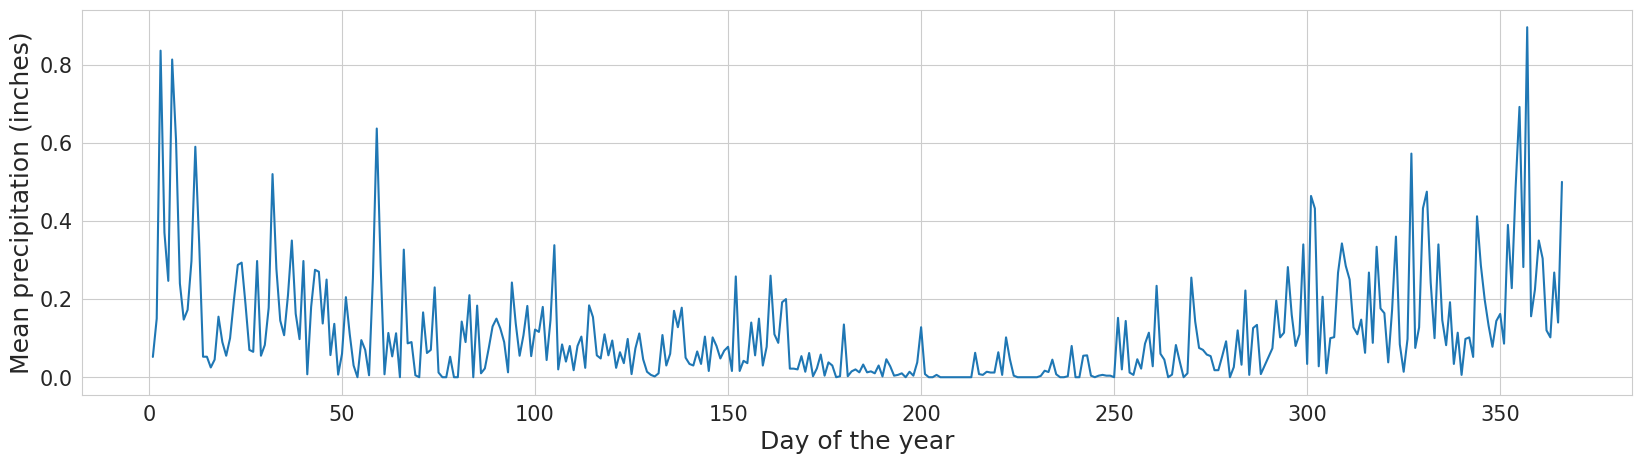

In [45]:
plt.figure(figsize =(20,5))

sns.lineplot(data = mean_day_precipitation('SEA'), x = 'day_of_year', y = 'precipitation')

plt.xlabel('Day of the year', fontsize = 18)
plt.ylabel('Mean precipitation (inches)', fontsize = 18)

plt.tick_params(labelsize = 15)
plt.show()

Over the five-year period, Seattle show a clear seasonal precipitaition pattern. Mean daily precipitation is highest in the winter, with peak close to 0.9 inches, while summer precipitation is much lower, generally staying below 0.15 inches. This suggests that Seattle is much wetter in the winter and relatively dry in the summer.

In [46]:
# mean precipitation in Berkley, average across year
mean_day_precipitation_berkeley = mean_day_precipitation('BER')
mean_day_precipitation_berkeley

,precipitation
day_of_year,
1,0.000000
2,0.028000
3,0.002000
4,0.114000
5,0.086000
...,...
362,0.000000
363,0.173333
364,0.000000


In [47]:
# Check if there is missing value in average across year
mean_day_precipitation_berkeley['precipitation'].isna().sum()

1

-> 1 missing in berkeley average across year

#### Fill the mean 366 day using K-Nearest Neighbors (KNN) imputation with k = 5 

In [48]:
from sklearn.impute import KNNImputer

# Convert day_of_year from index to a column
berkeley_mean = mean_day_precipitation_berkeley.reset_index()

# Create KNN imputer with k = 5
imputer = KNNImputer(n_neighbors=5)

# Impute the missing precipitation value
berkeley_mean[['day_of_year', 'precipitation']] = imputer.fit_transform(
    berkeley_mean[['day_of_year', 'precipitation']]
)
berkeley_mean['day_of_year'] = berkeley_mean['day_of_year'].astype(int)
mean_day_precipitation_berkeley = berkeley_mean.set_index('day_of_year')

In [49]:
# Check the mean of day 366
mean_day_precipitation_berkeley.loc[366]

precipitation    0.034667
Name: 366, dtype: float64

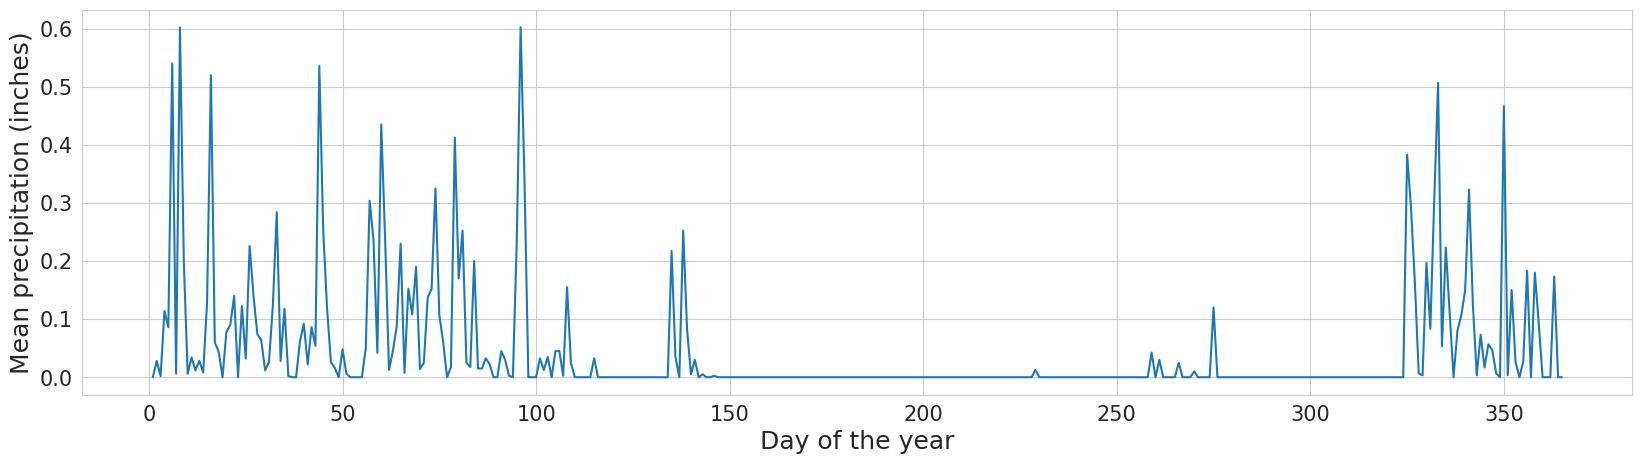

In [50]:
plt.figure(figsize =(20,5))

sns.lineplot(data = mean_day_precipitation('BER'), x = 'day_of_year', y = 'precipitation')

plt.xlabel('Day of the year', fontsize = 18)
plt.ylabel('Mean precipitation (inches)', fontsize = 18)

plt.tick_params(labelsize = 15)
plt.show()

Over the five-year period, Berkeley shows a clear seasonal precipitation pattern. Mean daily precipitation is highest during the winter and early spring, with peaks close to 0.6 inches. During the summer, precipitation is very low and often close to zero. This suggests that Berkeley has a distinct rainy season during the cooler months and a dry season during the summer.

### Replace missing value with average across year

In [51]:
# Find missing index of berkeley precipitation
indices_berkeley = np.where((df['precipitation'].isna() == True) & (df['city'] == 'BER'))[0]
indices_berkeley

array([ 638,  639,  640,  641,  642,  643,  644,  645,  646,  647,  648,
        649,  650,  651,  652,  653,  654,  655,  656,  657,  658,  659,
        660,  661,  662,  663,  664,  665,  666,  667,  668,  671, 1004,
       1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015,
       1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026,
       1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035, 1036, 1037,
       1038, 1039, 1040, 1041, 1042, 1043, 1044, 1045, 1046, 1047, 1048,
       1049, 1050, 1051, 1052, 1053, 1054, 1055, 1056, 1057, 1058, 1059,
       1060, 1061, 1062, 1063, 1064, 1065, 1066, 1067, 1068, 1069, 1070,
       1071, 1072, 1073, 1074, 1075, 1076, 1077, 1078, 1079, 1080, 1081,
       1082, 1083, 1084, 1085, 1086, 1087, 1088, 1089, 1090, 1091, 1092,
       1093, 1094, 1095, 1155, 1156, 1157, 1158, 1161, 1162, 1166, 1167,
       1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1179,
       1180, 1181, 1182, 1183, 1184, 1185, 1339, 13

In [52]:
df[(df['precipitation'].isna() == True) & (df['city'] == "BER")]

,date,city,precipitation,day_of_year
638,2019-10-01,BER,NaN,274
639,2019-10-02,BER,NaN,275
640,2019-10-03,BER,NaN,276
641,2019-10-04,BER,NaN,277
642,2019-10-05,BER,NaN,278
...,...,...,...,...
1821,2022-12-27,BER,NaN,361
1822,2022-12-28,BER,NaN,362
1823,2022-12-29,BER,NaN,363
1824,2022-12-30,BER,NaN,364


In [52]:
# Replace Berkeley's missing value with average across year 
for index in indices_berkeley:
    df.loc[index, 'precipitation'] = mean_day_precipitation_berkeley.loc[df.loc[index, 'day_of_year']].values[0]

In [53]:
# Find missing index of seattle precipitation
indices_seattle = np.where((df['precipitation'].isna() == True) & (df['city'] == 'SEA'))[0]
indices_seattle

array([1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844,
       1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855,
       1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866,
       1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877,
       1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888,
       1889, 1890, 1891, 1892, 1893, 1894, 1895, 2090, 2131, 2132, 2133,
       2134, 2135, 2136, 2137, 2138, 2139, 2140, 2195, 2196, 2197, 2214,
       2215, 2244, 2245, 2246, 2247, 2248, 2249, 2286, 2287, 2288, 2362,
       2363, 2368, 2369, 2370, 2371, 2372, 2373, 2374, 2375, 2376, 2377,
       2417, 2418, 2419, 2420, 2421, 2422, 2423, 2517, 2518, 2519, 2520,
       2521, 2522, 2523, 2524, 2559, 2560, 2561, 2602, 2603, 2604, 2605,
       2606, 2607, 2608, 2609, 2610, 2611, 2612, 2818, 2819, 2820, 2821,
       2822, 2823, 2824, 2825, 2826, 2827, 2972, 2973, 2974, 2975, 2983,
       2984, 2986, 2987, 2988, 3000, 3001, 3004, 30

In [54]:
# Replace Seattle's missing value with average across year 
for index in indices_seattle:
    df.loc[index, 'precipitation'] = mean_day_precipitation_seattle.loc[df.loc[index, 'day_of_year']].values[0]

In [55]:
# Double check again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[ns]
 1   city           3652 non-null   object        
 2   precipitation  3652 non-null   float64       
 3   day_of_year    3652 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(1)
memory usage: 100.0+ KB


### => No more missing value

## Export the clean .csv file

In [56]:
df.to_csv('clean_seattle_berkeley_weather.csv', encoding='utf-8-sig', index=False)

## Exploratory data analysis

Plot the daily precipitation for both cities on the same graph

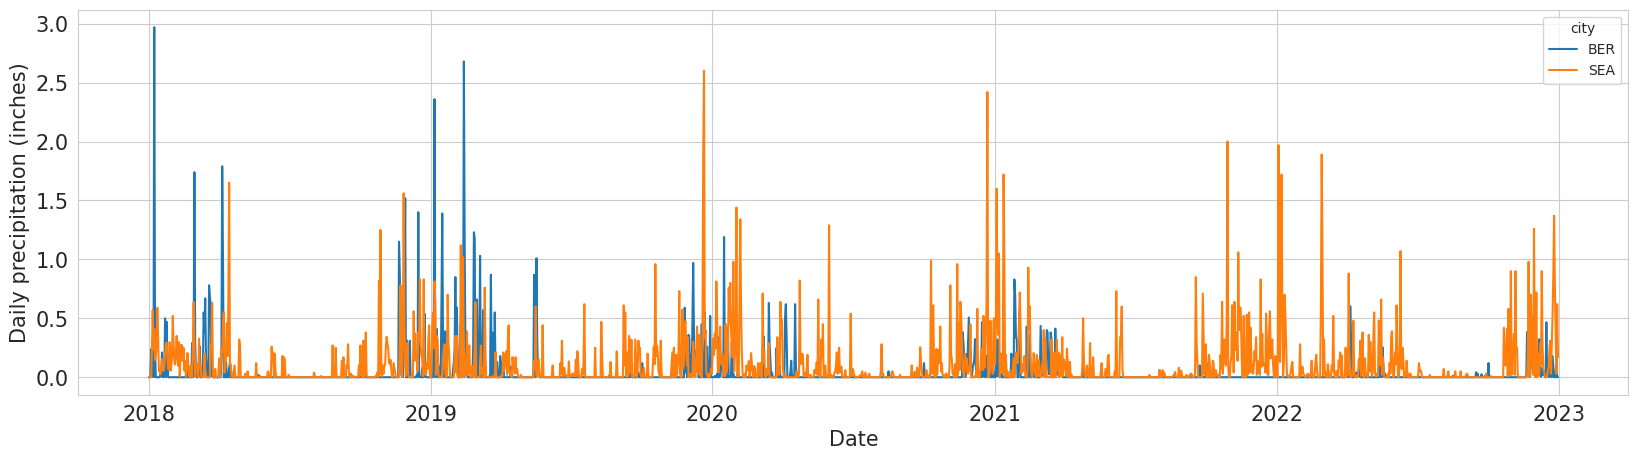

In [57]:
plt.figure(figsize = (20,5))

sns.lineplot(data = df, x = 'date', y = 'precipitation', hue = 'city')

plt.xlabel('Date', fontsize = 15)
plt.ylabel('Daily precipitation (inches)', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.show()

Berkeley shows several larger precipitation events in 2018 and 2019. However, from 2020 through 2022, Seattle generally experiences more frequent and higher precipitation events than Berkeley. Overall, the graph suggests that Seattle is wetter across most of the five-year period.

#### Compute basic numerical summaries for precipitation in each city

In [58]:
df[['city', 'precipitation']].groupby('city').describe()

precipitation                                                
             count      mean       std  min  25%   50%   75%   max
city                                                              
BER         1826.0  0.045362  0.187093  0.0  0.0  0.00  0.00  2.97
SEA         1826.0  0.113270  0.240516  0.0  0.0  0.01  0.12  2.60

Compare mean precipitation values averaged over all days

In [59]:
df[['city', 'precipitation']].groupby('city').mean()

,precipitation
city,
BER,0.045362
SEA,0.113270


Show the values as a bar graph

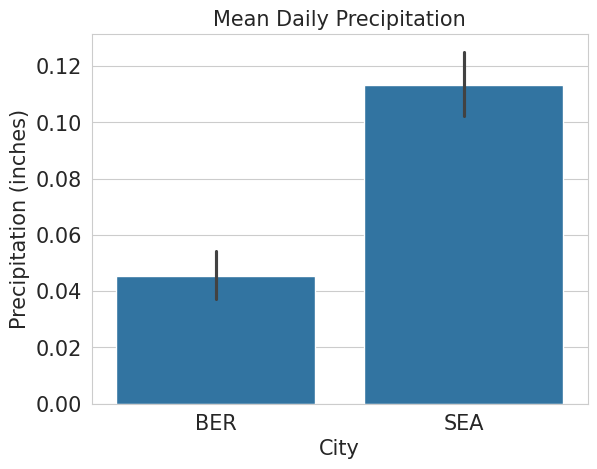

In [60]:
sns.barplot(data = df, x = 'city', y = 'precipitation')

plt.ylabel('Precipitation (inches)', fontsize = 15)
plt.xlabel('City', fontsize = 15)
plt.title('Mean Daily Precipitation', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.show()

Seattle has a higher average daily precipitation than Berkeley, with 0.113 inches per day compared with 0.045 inches per day, respectively.

#### Precipitation by month

Add a column to the data frame with the number of the month

In [61]:
df['month'] = pd.DatetimeIndex(df['date']).month

In [62]:
df.head()

,date,city,precipitation,day_of_year,month
0,2018-01-01,BER,0.00,1,1
1,2018-01-02,BER,0.00,2,1
2,2018-01-03,BER,0.00,3,1
3,2018-01-04,BER,0.24,4,1
4,2018-01-05,BER,0.03,5,1


In [63]:
df['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

Plot the distribution of precipitation amounts each month using boxplot

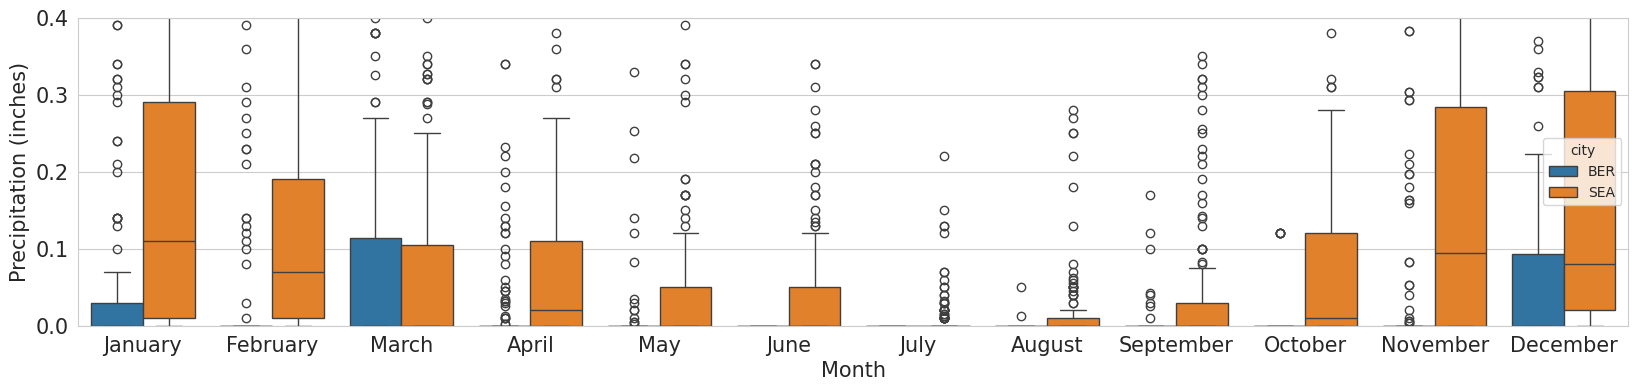

In [64]:
plt.figure(figsize = (20,4))

sns.boxplot(data = df, x = 'month', y = 'precipitation', hue = 'city')

plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)

plt.tick_params(labelsize = 15)

# Get month names and set as x-axis tick labels
import calendar
month_names = list(calendar.month_name[1:]) # Get month names
plt.xticks(ticks=range(12), labels = month_names) # Set x-axis ticks to month names

plt.ylim(0, 0.4) # Zoom in

plt.show()

Orient the plot horizontally

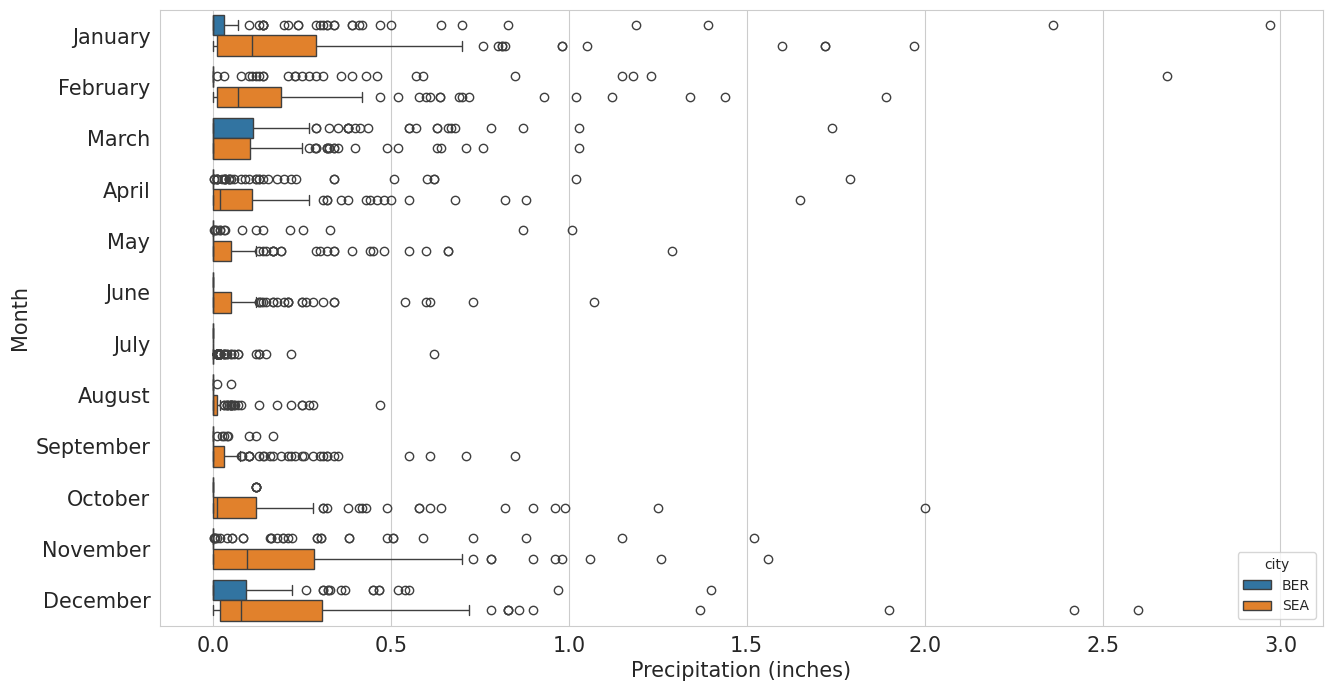

In [65]:
plt.figure(figsize = (15, 8))

sns.boxplot(data = df, x = 'precipitation', y = 'month', hue = 'city', orient = 'h')

plt.ylabel('Month', fontsize = 15)
plt.xlabel('Precipitation (inches)', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.yticks(ticks = range(12), labels = month_names)

plt.show()

#### Plot the mean precipitation each month

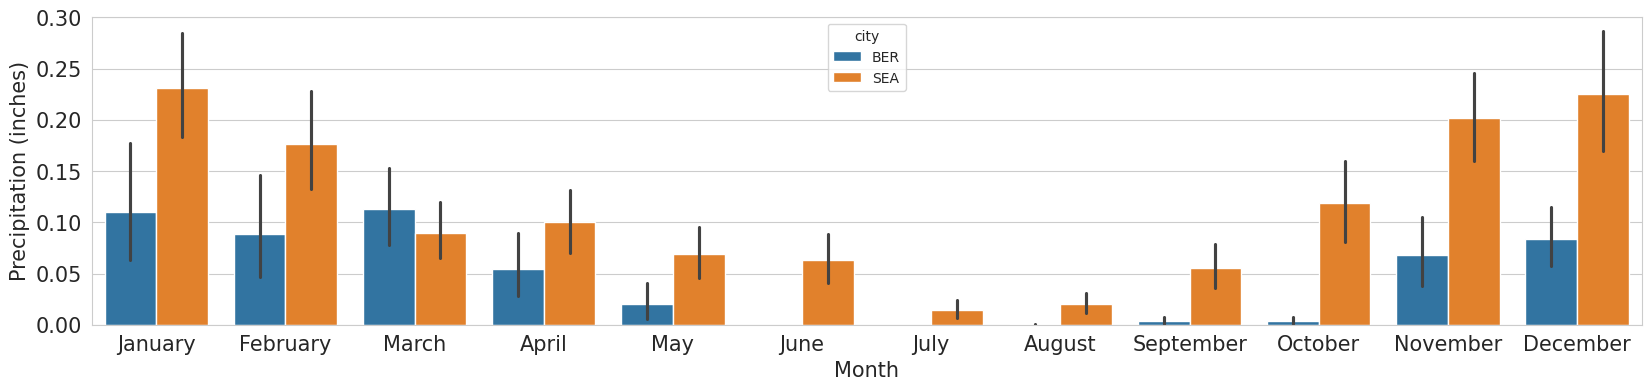

In [66]:
plt.figure(figsize = (20,4))

sns.barplot(data = df, x = 'month', y = 'precipitation', hue = 'city')

plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.xticks(ticks=range(12), labels = month_names) # Set x-axis ticks to month names

plt.show()

Seattle generally has greater mean daily precipitation than Berkley. The largest different occur during the fall and winter month. Berkley has very littel precipitation during the summer, while Seattle continue receive some precipition.

#### Compute the mean precipitation each month

In [67]:
df[['month', 'precipitation', 'city']].groupby([ 'month','city']).mean()

precipitation
month city               
1     BER        0.110323
      SEA        0.230742
2     BER        0.088936
      SEA        0.176472
3     BER        0.113129
      SEA        0.089075
4     BER        0.054583
      SEA        0.100483
5     BER        0.020323
      SEA        0.069161
6     BER        0.000000
      SEA        0.063167
7     BER        0.000000
      SEA        0.013984
8     BER        0.000403
      SEA        0.019995
9     BER        0.003583
      SEA        0.055622
10    BER        0.003871
      SEA        0.118452
11    BER        0.067933
      SEA        0.201867
12    BER        0.083406
      SEA        0.224903

Plot the proportion of days with any precipitation

In [68]:
df['any_precipitation'] = df['precipitation'] > 0

In [69]:
df.head()

,date,city,precipitation,day_of_year,month,any_precipitation
0,2018-01-01,BER,0.00,1,1,False
1,2018-01-02,BER,0.00,2,1,False
2,2018-01-03,BER,0.00,3,1,False
3,2018-01-04,BER,0.24,4,1,True
4,2018-01-05,BER,0.03,5,1,True


#### Plot the proportion of days with any precipitation over the 5 years

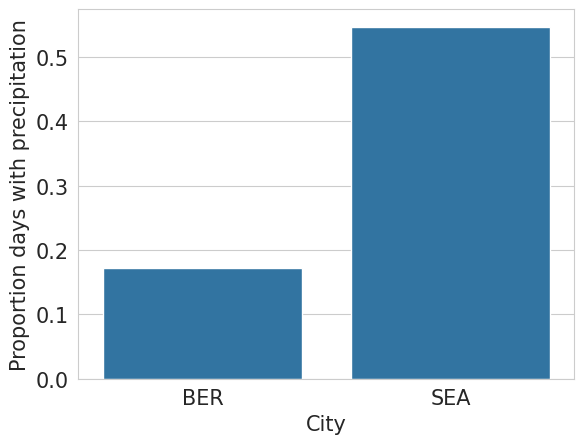

In [70]:
sns.barplot(data = df, x= 'city', y = 'any_precipitation', errorbar = None)

plt.xlabel('City', fontsize = 15)
plt.ylabel('Proportion days with precipitation', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.show()

#### Plot the proportion of days with precipitation each month

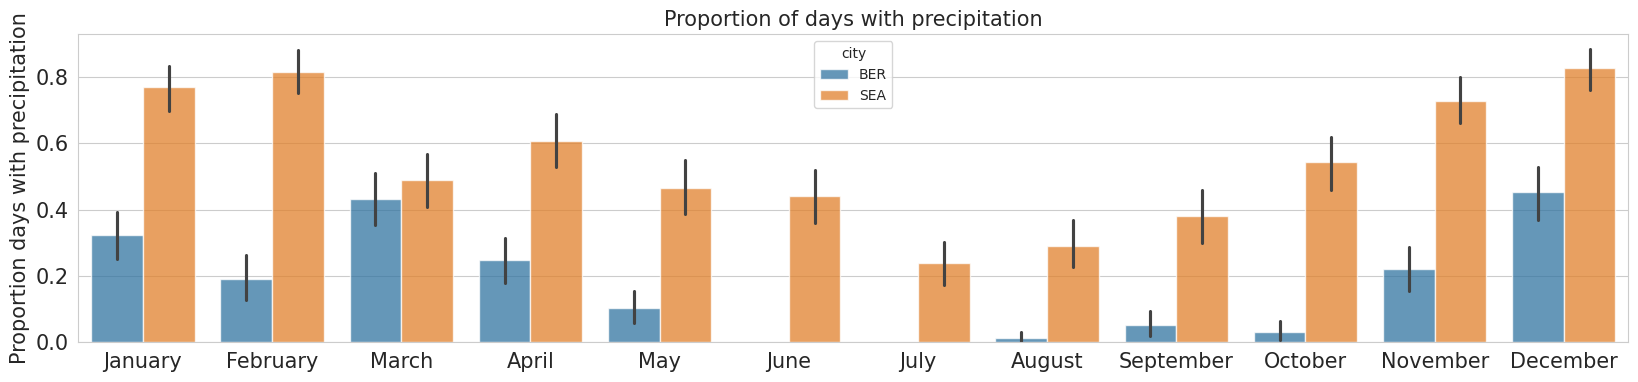

In [71]:
plt.figure(figsize =(20,4))

sns.barplot(data = df, x = 'month', y = 'any_precipitation', hue = 'city', alpha = 0.75)

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize = 15)
plt.title('Proportion of days with precipitation', fontsize = 15)

plt.xticks(ticks = range(12), labels = month_names)
plt.tick_params(labelsize = 15)

plt.show()

The proportion of rainy days in March is quite similar, but it is very different in June and July because there is almost no rain in Berkeley during those months.

#### Precipitation by season

In [72]:
# Function to seperate season by month
def get_season(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'winter'

In [73]:
df['season'] = df['month'].apply(get_season)

In [74]:
df['year'] = df['date'].dt.year

In [75]:
df.head()

,date,city,precipitation,day_of_year,month,any_precipitation,season,year
0,2018-01-01,BER,0.00,1,1,False,winter,2018
1,2018-01-02,BER,0.00,2,1,False,winter,2018
2,2018-01-03,BER,0.00,3,1,False,winter,2018
3,2018-01-04,BER,0.24,4,1,True,winter,2018
4,2018-01-05,BER,0.03,5,1,True,winter,2018


### Computer sum precipitation by season each year

In [88]:
df_season = df.groupby(['year','season','city'])['precipitation'].sum()
df_season = df_season.reset_index()
df_season

,year,season,city,precipitation
0,2018,fall,BER,5.130000
1,2018,fall,SEA,10.271667
2,2018,spring,BER,9.870000
3,2018,spring,SEA,8.692500
4,2018,summer,BER,0.000000
5,2018,summer,SEA,2.060000
6,2018,winter,BER,8.550000
7,2018,winter,SEA,16.220000
8,2019,fall,BER,1.420000
9,2019,fall,SEA,10.905000


In [90]:
df_season[df_season['season'] == "fall"]

,year,season,city,precipitation
0,2018,fall,BER,5.130000
1,2018,fall,SEA,10.271667
8,2019,fall,BER,1.420000
9,2019,fall,SEA,10.905000
16,2020,fall,BER,2.336667
17,2020,fall,SEA,10.126667
24,2021,fall,BER,0.220000
25,2021,fall,SEA,16.750000
32,2022,fall,BER,2.220833
33,2022,fall,SEA,8.930000


In [86]:
# Sort the year follow winter, spring, summer, fall oreder
season_order = ['winter','spring', 'summer', 'fall']
years = sorted(df_season['year'].unique())

# Give each season/year combination a position
season_position = { 'winter': 0,'spring': 1, 'summer': 2, 'fall': 3}

year_position = {year: i for i, year in enumerate(years)}

df_season['x_position'] = (
    df_season['year'].map(year_position) * 4
    + df_season['season'].map(season_position)
)

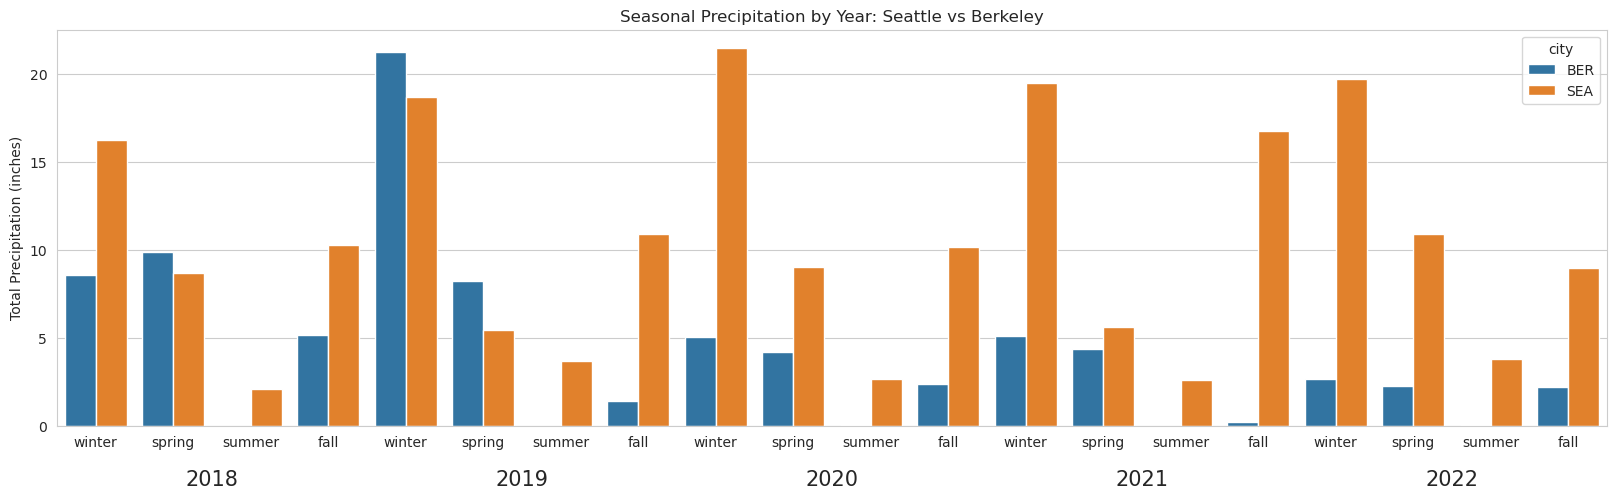

In [87]:
# Plot
plt.figure(figsize=(20, 6))

ax = sns.barplot( data=df_season, x='x_position', y='precipitation', hue='city')

# Season labels
ax.set_xticks(range(len(years) * 4))
ax.set_xticklabels(season_order * len(years))

# Year labels underneath each group of seasons
for i, year in enumerate(years):
    center = i * 4 + 1.5
    ax.text( center, -0.15, str(year), ha='center', transform=ax.get_xaxis_transform(), fontsize=15)

#Label
plt.xlabel('')
plt.ylabel('Total Precipitation (inches)')
plt.title('Seasonal Precipitation by Year: Seattle vs Berkeley')

plt.subplots_adjust(bottom=0.22)

plt.show()

Berkeley experienced unusually high total precipitation during winter 2019, exceeding Seattle during that season. This was an exceptional period compared with most other years, when Seattle generally received more precipitation than Berkeley.

#### More information related to this unusual event

Berkeley experienced unusually high precipitation during the 2018–2019 winter. Northern California was affected by a series of Pacific storms and atmospheric rivers, including a moderate-to-strong atmospheric river in January and another major event in mid-February. These systems transported large amounts of moisture from the Pacific Ocean into California, producing heavy rainfall across the Bay Area.

https://news.berkeley.edu/2019/01/18/this-weeks-rains-pushed-precipitation-above-average-but-average-isnt-enough/

The broader atmospheric pattern also contributed to the wet winter. A weak El Niño developed during this period, while changes in the Pacific jet stream helped direct moisture-rich storms toward California. Additionally, shorter-term atmospheric patterns and repeated atmospheric river events were important drivers.

https://www.noaa.gov/news/us-records-wettest-winter-capped-by-cooler-wetter-february-2019

Overall, the repeated storms help explain why Berkeley had exceptionally high precipitation during this period compared with the other years in the dataset. NOAA reported that much of the western United States experienced above-average precipitation during the December 2018–February 2019 winter.

## Analysis

#### Perfrom a statistical test for differences in the mean precipitation each month between the cities

H0: mean seattle for each month  = mean berkeley for each month

Ha: mean seattle for each month != mean berkeley for each month

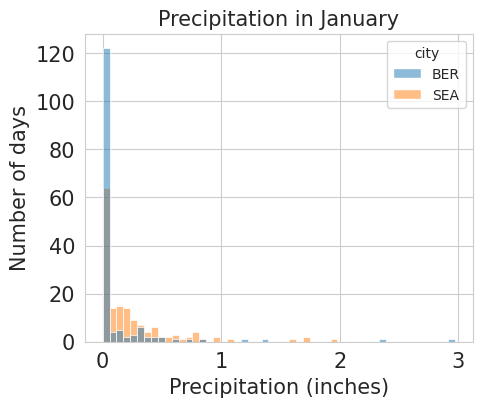

In [72]:
plt.figure(figsize = (5,4))

sns.histplot(data = df.loc[df['month'] == 1], x = 'precipitation', hue = 'city')

plt.xlabel('Precipitation (inches)', fontsize = 15)
plt.ylabel('Number of days', fontsize = 15)
plt.title('Precipitation in January', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.show()

Use t test as an approximate test

In [73]:
from scipy import stats

In [74]:
significance_level = 0.05
significantly_different = np.zeros(12)

# Perform t-test for each month
for month in range(1, 13):
    # Get precipitation data for Seattle and Berkeley for the current month
    sea_data = df.loc[(df['city'] == 'SEA') & (df['month'] == month), 'precipitation']
    ber_data = df.loc[(df['city'] == 'BER') & (df['month'] == month), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, ber_data, equal_var = False)

    if p_value < significance_level:
        significantly_different[month - 1] = 1
        
    print(f"Month {month}:")
    print(f"  t-statistic = {t_statistic:.2f}")
    print(f"  p-value t test = {p_value:.3f}")
    print("-" * 20)

Month 1:
  t-statistic = 3.03
  p-value t test = 0.003
--------------------
Month 2:
  t-statistic = 2.45
  p-value t test = 0.015
--------------------
Month 3:
  t-statistic = -1.03
  p-value t test = 0.304
--------------------
Month 4:
  t-statistic = 2.00
  p-value t test = 0.046
--------------------
Month 5:
  t-statistic = 3.05
  p-value t test = 0.003
--------------------
Month 6:
  t-statistic = 5.29
  p-value t test = 0.000
--------------------
Month 7:
  t-statistic = 3.05
  p-value t test = 0.003
--------------------
Month 8:
  t-statistic = 3.97
  p-value t test = 0.000
--------------------
Month 9:
  t-statistic = 4.73
  p-value t test = 0.000
--------------------
Month 10:
  t-statistic = 5.47
  p-value t test = 0.000
--------------------
Month 11:
  t-statistic = 4.76
  p-value t test = 0.000
--------------------
Month 12:
  t-statistic = 4.20
  p-value t test = 0.000
--------------------


Plot the mean precipitation each month with a star for significant differences

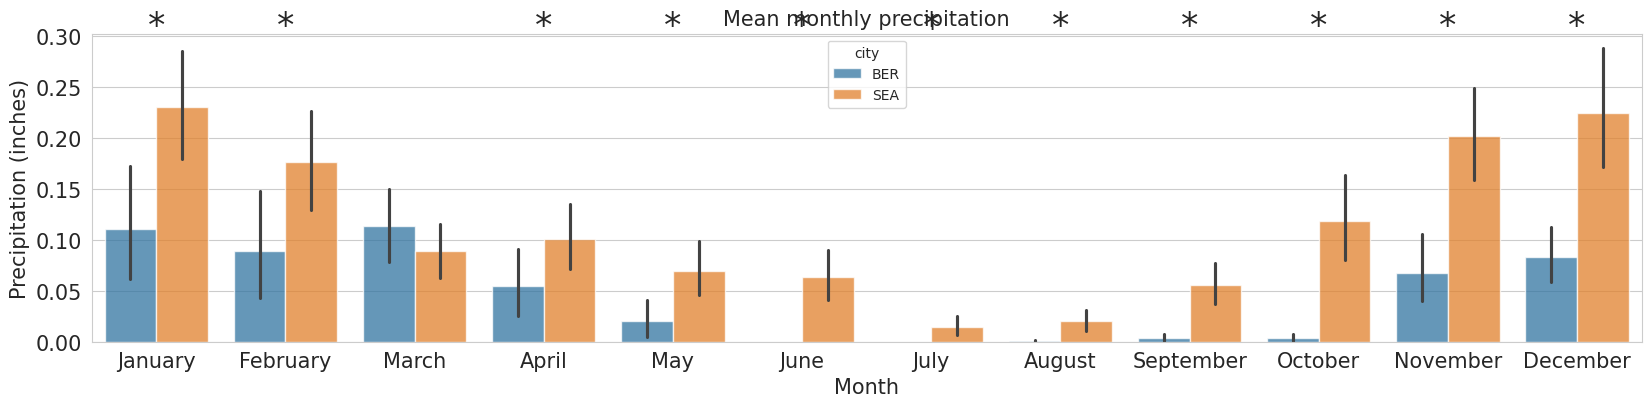

In [75]:
plt.figure(figsize =(20,4))

sns.barplot(data = df, x = 'month', y = 'precipitation', hue = 'city', alpha = 0.75)

plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)
plt.title('Mean monthly precipitation', fontsize = 15)

plt.xticks(ticks = range(12), labels = month_names)
plt.tick_params(labelsize = 15)

# Add stars for significantly different months
for month in range(12):
    if significantly_different[month] == 1:

        # Add a star
        plt.text(month, 0.3, '*', ha = 'center', fontsize = 25)


plt.show()

The difference in precipitation of all month except March between Seattle and Berkeley is statistically significant because the p-value is below 0.05.

#### Perform a statistical test for differences in the proportion of days with any precipitation each month between the cities

H0: p seattle for each month  = p berkeley for each month

Ha: p seattle for each month != p berkeley for each month

In [76]:
from statsmodels.stats.proportion import proportions_ztest

significance_level = 0.05
significantly_different_proportion = np.zeros(12)

# Perform t-test for each month
for month in range(1, 13):

    # Create a contingency table for Seattle and Berkeley for the current month:
    contingency_table = pd.crosstab(
        df.loc[df['month'] == month, 'city'], df.loc[df['month'] == month, 'any_precipitation']
    )

    # Calculate the number of True values (days with precipitation) for each city
    days_with_precipitation = contingency_table[True]

    # Calculate the total number of days for each city
    total_counts = contingency_table.sum(axis = 1)

    # Hypothesis test
    zstat, p_value = proportions_ztest(
        count = days_with_precipitation, nobs = total_counts, alternative = 'two-sided'
    )

    if p_value < significance_level:
        significantly_different_proportion[month - 1] = 1

    print(f"Month {month}:")
    print(f"  z-statistic = {zstat:.2f}")
    print(f"  p-value = {p_value:.3f}")
    print("-" * 20)

Month 1:
  z-statistic = -7.87
  p-value = 0.000
--------------------
Month 2:
  z-statistic = -10.48
  p-value = 0.000
--------------------
Month 3:
  z-statistic = -1.03
  p-value = 0.305
--------------------
Month 4:
  z-statistic = -6.30
  p-value = 0.000
--------------------
Month 5:
  z-statistic = -7.05
  p-value = 0.000
--------------------
Month 6:
  z-statistic = -9.20
  p-value = 0.000
--------------------
Month 7:
  z-statistic = -6.48
  p-value = 0.000
--------------------
Month 8:
  z-statistic = -6.81
  p-value = 0.000
--------------------
Month 9:
  z-statistic = -6.87
  p-value = 0.000
--------------------
Month 10:
  z-statistic = -9.92
  p-value = 0.000
--------------------
Month 11:
  z-statistic = -8.79
  p-value = 0.000
--------------------
Month 12:
  z-statistic = -6.86
  p-value = 0.000
--------------------


In [77]:
contingency_table = pd.crosstab(
    df.loc[df['month'] == 1, 'city'], df.loc[df['month'] == 1, 'any_precipitation']
)
contingency_table

any_precipitation,False,True
city,,
BER,105,50
SEA,36,119


Plot the proportion of days with any precipitation each month with a star for significant diffrences

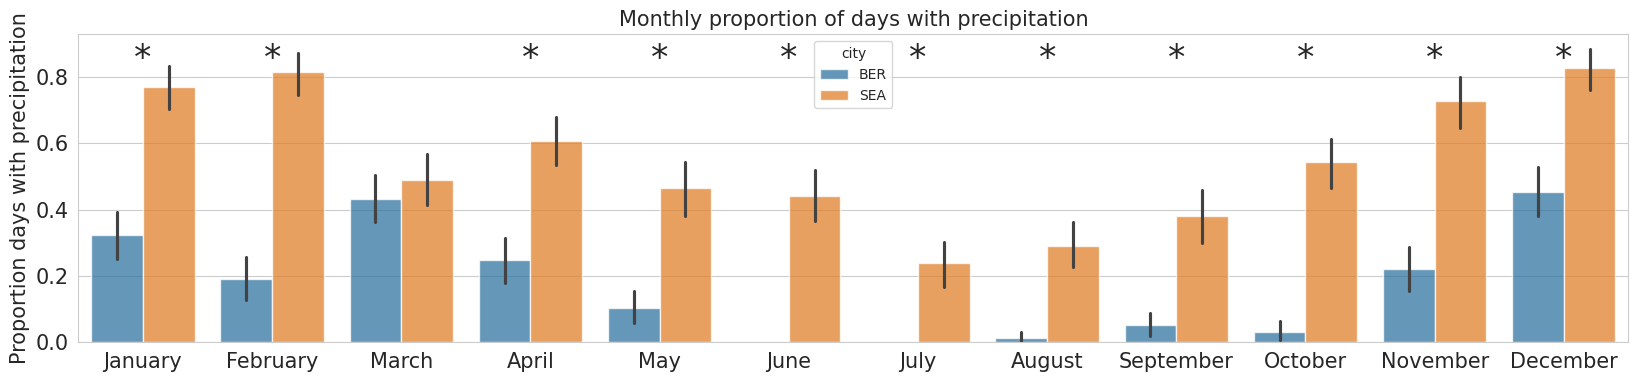

In [78]:
plt.figure(figsize =(20,4))

sns.barplot(data = df, x = 'month', y = 'any_precipitation', hue = 'city', alpha = 0.75)

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize = 15)
plt.title('Monthly proportion of days with precipitation', fontsize = 15)

plt.xticks(ticks = range(12), labels = month_names)
plt.tick_params(labelsize = 15)

# Add stars for significantly different months
for month in range(12):
    if significantly_different[month] == 1:

        # Add a star
        plt.text(month, 0.825, '*', ha = 'center', fontsize = 25)


plt.show()

Like t-test, the difference in precipitation of all month except March between Seattle and Berkeley is statistically significant because the p-value is below 0.05.